In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filenames
downloadsByCountry_file = "data/CMIP6downloadsByCountry_13_01_2025.csv"
downloadsByHost_file = ""
dataByInstitute_file = "data/cmip6-institutes_13_01_2025.csv"

# Remove strange characters from CSV files
for file in [downloadsByCountry_file, dataByInstitute_file]:
    with open(file, "r", encoding="utf-8", errors="replace") as f:
        content = f.read()
    with open(file, "w", encoding="utf-8") as f:
        f.write(content)

# Load CSV files
downloadsByCountry = pd.read_csv(downloadsByCountry_file, encoding="utf-8")  
downloadsByHost = ""
dataByInstitute = pd.read_csv(dataByInstitute_file, encoding="utf-8") 

# Display first few rows
print(downloadsByCountry.head())
print("=====")
print(dataByInstitute.head())

   num_downloads  downloaded_data  country
0       39597081      11168000.68      USA
1       68623384       3480519.00    China
2        8386889       1603986.37   France
3        6005376       1532490.41       UK
4        3395586       1376526.45  Germany
=====
  Institute  Country  number_of_datasets  total_size_TB
0       AER      USA                  24           0.00
1   AS-RCEC   Taiwan              106780         245.69
2       AWI  Germany              146457         335.52
3       BCC    Spain              142028         407.61
4      CAMS    China                6807          25.37


In [9]:
# Find common countries in downloads by Institute and by country:
common_elements_CountryInstitute = set(downloadsByCountry["country"]) & set(dataByInstitute["Country"])
print(common_elements_CountryInstitute)

{'Norway', 'China', 'France', 'Spain', 'Australia', 'Taiwan', 'Italy', 'Korea', 'India', 'Germany', 'Canada', 'New Zealand', 'UK', 'Japan', 'USA', 'Russia'}


In [3]:
downloadsCountryAndInstitute = pd.DataFrame({
    'country': sorted(common_elements_CountryInstitute),
    'downCountry': 0.,
    'downHost' : 0.
})

for ii, country in enumerate(common_elements_CountryInstitute):
    downloadsCountryAndInstitute.loc[ii, "downCountry"] = downloadsByCountry[downloadsByCountry['country'] == country]['downloaded_data'].sum()
    downloadsCountryAndInstitute.loc[ii, "downInst"] = dataByInstitute[dataByInstitute['Country'] == country]['total_size_TB'].sum()*1.e3

downloadsCountryAndInstitute["ratioInstCountry"] = downloadsCountryAndInstitute["downInst"]/downloadsCountryAndInstitute["downCountry"]

print(downloadsCountryAndInstitute)

        country  downCountry  downHost   downInst  ratioInstCountry
0     Australia    411301.28       0.0   845980.0          2.056838
1        Canada   3480519.00       0.0   683390.0          0.196347
2         China   1603986.37       0.0  5882140.0          3.667201
3        France    558692.70       0.0   407610.0          0.729578
4       Germany    742126.28       0.0   866250.0          1.167254
5         India    261266.07       0.0   250670.0          0.959443
6         Italy    321525.68       0.0   619600.0          1.927062
7         Japan    940026.43       0.0   152000.0          0.161698
8         Korea    378357.34       0.0    79890.0          0.211150
9   New Zealand   1376526.45       0.0  4093380.0          2.973702
10       Norway    475912.98       0.0   974790.0          2.048253
11       Russia    152768.83       0.0     6120.0          0.040061
12        Spain   1532490.41       0.0  2322600.0          1.515572
13       Taiwan   1147969.61       0.0  3653580.

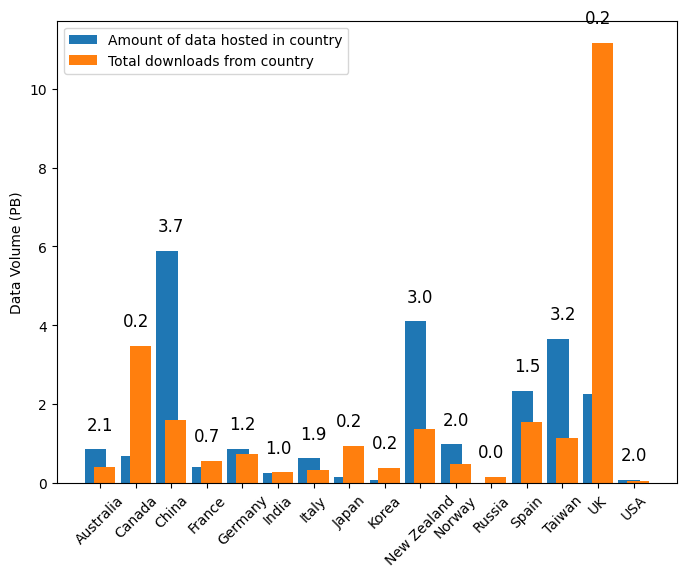

In [4]:
# Plot

# Plot settings
fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(downloadsCountryAndInstitute['country']))  # X-axis positions
width = 0.6  # Bar width

# Plot 'downInst' bars on top of 'downCountry'
bars2 = ax.bar(x-0.125, downloadsCountryAndInstitute['downInst']/1e6, width, label='Amount of data hosted in country')

# Plot 'downCountry' bars
bars1 = ax.bar(x+0.125, downloadsCountryAndInstitute['downCountry']/1e6, width, label='Total downloads from country')

# Annotate ratioInstCountry above bars
for i, (bar1, bar2, ratio) in enumerate(zip(bars1, bars2, downloadsCountryAndInstitute['ratioInstCountry'])):
    height = max(bar2.get_height(), bar1.get_height())
    ax.text(bar1.get_x() + bar1.get_width()/2 -0.125, height + .5, f'{ratio:.1f}', ha='center', fontsize=12) #, fontweight='bold')

# Labels and legend
ax.set_xlabel("")
ax.set_ylabel("Data Volume (PB)")
ax.set_title("")
ax.set_xticks(x)
plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
ax.set_xticklabels(downloadsCountryAndInstitute['country'])
ax.legend()

# Show plot
plt.show()

In [5]:
# Re-do analysis by continent

# Filenames
downloadsByContinent_file = "data/CMIP6downloadsByContinent_13_01_2025.csv"

# Remove weird characters from CSV files
for file in [downloadsByContinent_file]:
    with open(file, "r", encoding="utf-8", errors="replace") as f:
        content = f.read()
    with open(file, "w", encoding="utf-8") as f:
        f.write(content)

# Load CSV files
downloadsByContinent = pd.read_csv(downloadsByContinent_file, encoding="utf-8")  

downloadsByContinent = downloadsByContinent.sort_values(by='continent')

# Display first few rows
print(downloadsByContinent)

   num_downloads  downloaded_data      continent
5         578151        171900.87         Africa
6           3239            47.74     Antarctica
2       88906060       7449871.77           Asia
1       38539823       8145544.55         Europe
0       43171986      11678357.94  North America
3        2902700        894903.07        Oceania
4        1281940        281575.56  South America


In [6]:
# Create Dataframe combining the data

downloadsContinentAndInst = pd.DataFrame({
    'continent': downloadsByContinent['continent'],
    'downContinent': downloadsByContinent['downloaded_data'],
    'downHost' : 0.
})

downloadsContinentAndInst.loc[downloadsContinentAndInst['continent'] == 'North America', "downInst"] = (
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'USA']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Canada']['downInst'].sum())

downloadsContinentAndInst.loc[downloadsContinentAndInst['continent'] == 'Oceania', "downInst"] = (
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Australia']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'New Zealand']['downInst'].sum())

downloadsContinentAndInst.loc[downloadsContinentAndInst['continent'] == 'Europe', "downInst"] = (
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'France']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Germany']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Italy']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Spain']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'UK']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Norway']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Russia']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Sweden']['downInst'].sum())

downloadsContinentAndInst.loc[downloadsContinentAndInst['continent'] == 'Asia', "downInst"] = (
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'China']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'India']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Korea']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Taiwan']['downInst'].sum() + 
    downloadsCountryAndInstitute[downloadsCountryAndInstitute['country'] == 'Japan']['downInst'].sum())

downloadsContinentAndInst['downContinent'] = round(downloadsContinentAndInst['downContinent'], 1)
downloadsContinentAndInst['downInst'] = round(downloadsContinentAndInst['downInst'], 1)

downloadsContinentAndInst['downInst'] = downloadsContinentAndInst['downInst'].fillna(0)

downloadsContinentAndInst['ContInst_ratio'] = round(downloadsContinentAndInst['downContinent'] / downloadsContinentAndInst['downInst'], 2)

downloadsContinentAndInst['ContInst_ratio'] = downloadsContinentAndInst['ContInst_ratio'].replace([np.inf, -np.inf], np.nan)

print(downloadsContinentAndInst)
print("======")
print("Sum downContinent: ",  round(downloadsContinentAndInst['downContinent'].sum(), 1), ", sum downInst: ", round(downloadsContinentAndInst['downInst'].sum(), 1))


       continent  downContinent  downHost    downInst  ContInst_ratio
5         Africa       171900.9       0.0         0.0             NaN
6     Antarctica           47.7       0.0         0.0             NaN
2           Asia      7449871.8       0.0  10018280.0            0.74
1         Europe      8145544.6       0.0   7452060.0            1.09
0  North America     11678357.9       0.0    763940.0           15.29
3        Oceania       894903.1       0.0   4939360.0            0.18
4  South America       281575.6       0.0         0.0             NaN
Sum downContinent:  28622201.6 , sum downInst:  23173640.0


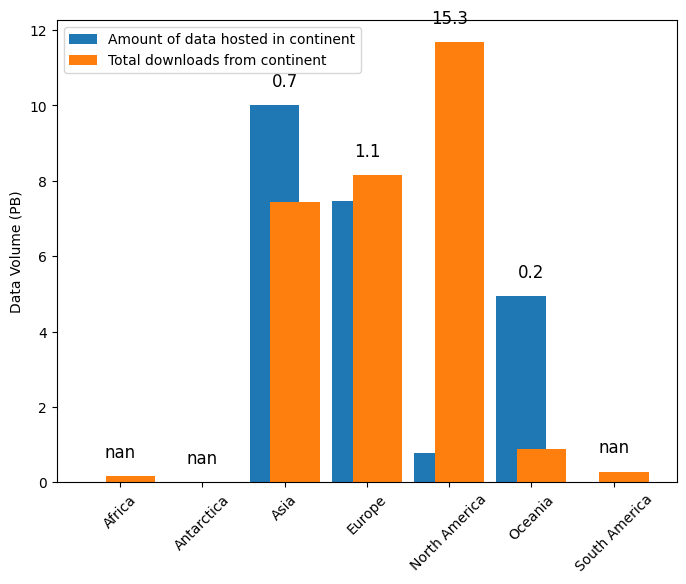

In [7]:
# Plot

# Plot settings
fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(downloadsContinentAndInst['continent']))  # X-axis positions
width = 0.6  # Bar width

# Plot 'downInst' bars on top of 'downContinent'
bars2 = ax.bar(x-0.125, downloadsContinentAndInst['downInst']/1e6, width, label='Amount of data hosted in continent')

# Plot 'downContinent' bars
bars1 = ax.bar(x+0.125, downloadsContinentAndInst['downContinent']/1e6, width, label='Total downloads from continent')

# Annotate ratioInstContinent above bars
for i, (bar1, bar2, ratio) in enumerate(zip(bars1, bars2, downloadsContinentAndInst['ContInst_ratio'])):
    height = max(bar2.get_height(), bar1.get_height())
    ax.text(bar1.get_x() + bar1.get_width()/2 -0.125, height + .5, f'{ratio:.1f}', ha='center', fontsize=12) #, fontweight='bold')

# Labels and legend
ax.set_xlabel("")
ax.set_ylabel("Data Volume (PB)")
ax.set_title("")
ax.set_xticks(x)
plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
ax.set_xticklabels(downloadsContinentAndInst['continent'])
ax.legend()

# Show plot
plt.show()